In [1]:
import sys
sys.path.insert(1, '../src/')
from data_utils import *
from train_and_evaluate import *

import json

with open('../config.json', 'r') as f:
    config = json.load(f)

ELEMENTS_TO_KEEP = config["elements_to_keep"]
ELEMENTS_TO_KEEP_NO_FE = [el for el in ELEMENTS_TO_KEEP if el != 'Fe']

PREDICTION_PATH_DICT = config["prediction_path"]
PREPROCESSED_DATA_PATH_DICT = config["preprocessed_data_path"]
FIGURES_PATH = config["figures_path"]['all']


DATASETS = ['Konstytucja', 'corroded', 'Merkuriusz', 'Kopernik']

CMAP = plt.get_cmap('tab20')

In [2]:
df, y_true = join_datasets_into_one(
                            DATASETS, 
                            PREDICTION_PATH_DICT,
                            PREPROCESSED_DATA_PATH_DICT,
                            ELEMENTS_TO_KEEP_NO_FE
                            )

X = np.array(df.values)

In [3]:
from sklearn.decomposition import PCA

n_components = 3
pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X)

In [4]:
# principal components, i.e. directions of the greatest variance in space (perpendicular to one another)
pca.components_

array([[ 0.06301115,  0.16683985, -0.03296961,  0.45034863,  0.53841691,
         0.37676685,  0.55620285, -0.04366607,  0.14552945],
       [ 0.49332248,  0.38342419,  0.72039029,  0.00114547, -0.01093986,
         0.10794936, -0.14947263,  0.21756112, -0.09595665],
       [ 0.08633439, -0.30667783, -0.15846229, -0.07128996, -0.32453822,
         0.71797125,  0.05722978,  0.42629194, -0.24998937]])

In [5]:
# principal components, i.e. directions of the greatest variance in space (perpendicular to one another)
pca.explained_variance_ratio_

array([0.48542122, 0.2004041 , 0.13853722])

In [6]:
# elements corresponding to consecutive dimensions
print(ELEMENTS_TO_KEEP_NO_FE)

['Al', 'S', 'Cr', 'Mn', 'Co', 'Cu', 'Zn', 'Pb', 'Mg']


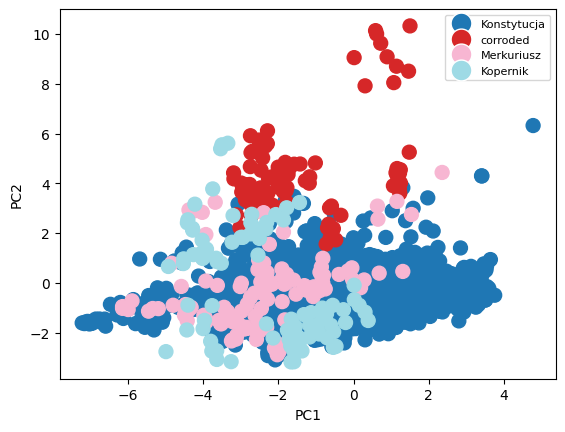

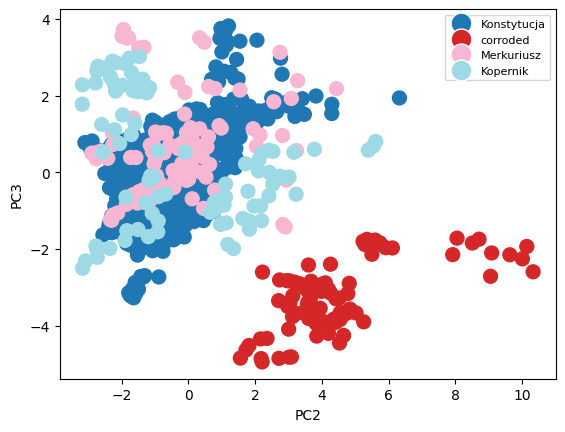

In [7]:
visualise_pca(X_pca, y_true, dimensions=[0,1], whether_sort=False, figures_path=None)

visualise_pca(X_pca, y_true, dimensions=[1, 2], whether_sort=False, figures_path=None)

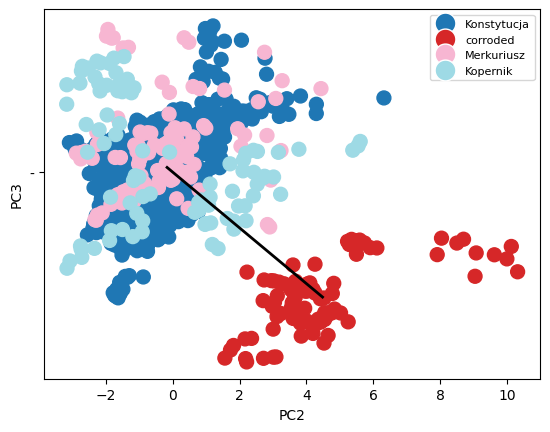

In [14]:
# let's choose some interesting dimensions and project data onto it
dimensions=[1,2]

pc1 = X_pca[:, dimensions[0]]
pc2 = X_pca[:, dimensions[1]]
X_2d = np.column_stack((pc1, pc2))

# let's find means of class 'not corroded' and 'corroded' (on PC plane, 2D)
class0 = X_2d[y_true != 'corroded']
class1 = X_2d[y_true == 'corroded']

mu0 = class0.mean(axis=0)
mu1 = class1.mean(axis=0)

# let's draw a vector from mu0 to m1 just using simple formula t*mu0 + (1-t)*mu1 (all points in between)
t = np.linspace(0, 1, 100)
x_interval = mu0[0]*t + (1-t) * mu1[0]
y_interval = mu0[1]*t + (1-t) * mu1[1]

plt.plot(x_interval, y_interval, 'black', '-', linewidth=2)

visualise_pca(X_pca, y_true, dimensions=[1, 2], whether_sort=False, figures_path=None)

In [19]:
#vector from not corroded to corroded (on PC plane, 2D)
w = mu1 - mu0
w = w.reshape(1,-1) #to get horizontal vector

# the entries of vector w are the coefficients in the PC basis
# so the actual vector w in standard basis is different
# it is a sum of two vectors: first PC rescaled by w[0] plus second PC rescaled by w[1]
# so to get the equivalent of w in high dimensional space we need matrix multiplication
vector_in_9d = w @ pca.components_[dimensions, :]
vector_in_9d
# now the consecutive entries of this vector correspond to consecutive elements from ELEMENTS_TO_KEEP_NO_FE list
# those elements that correspond to positive entries pull the point towards corroded group
# (are consistent with the direction of vector mu1-mu0, i.e. from mu0 to mu1
# those that correspond to negative entries pull toward not corroded group

In [24]:
# sanity check: project it back to 2D PC plane
# we should get exactly mu1-mu0
V = pca.components_[dimensions]
res = V @ vector_in_9d.T
print(res)
print('-------------')
print(mu1-mu0)
print('-------------')
# ok

[[ 4.65655917]
 [-3.37750743]]
-------------
[ 4.65655917 -3.37750743]
-------------


In [26]:
# ATTENTION
# pca.transform will not work
pca.transform(vector_in_9d)[:, dimensions]
# it is not equal to mu1-mu0, because transform also does shifting (centering)

array([[15.58737319, -1.50645027]])